In [1]:
%matplotlib inline
import os, warnings
warnings.filterwarnings('ignore')
import sys
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import gaussian_filter
from IPython.display import display

import pynapple as nap
from spatial_manifolds.detect_grids import *
from spatial_manifolds.toroidal import spectral_analysis

In [2]:
SOURCE_PATH  = '/Users/harryclark/Downloads/COHORT12/'
OUT_DIR      = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_6_task_anchoring/'

bs  = 2    # cm per position bin
tl  = 200  # track length (cm)
bpt = int(tl / bs)
TARGET_FREQS = np.arange(1, 6) * bs / tl

GC_COLOR  = '#c04744'
NGS_COLOR = '#3171ae'
NS_COLOR  = '#888888'

CMAP_TA = ListedColormap(['#e7d7e8', '#9d5391', 'white'])
NORM_TA = BoundaryNorm([-0.5, 0.5, 1.5, 2], CMAP_TA.N)

REGIONS_KEEP = ('ENT', 'PAR')
GAP_COLS     = 2   # NaN columns between shanks in population raster

SESSIONS = [
    (25, 24, None),
    (25, 25, None),
    (26, 18, None),
    (26, 19, None),
]

N_RANDOM    = 4
SIGMA_TC    = 2.5
EDGE_TRIALS = int(1600 / (2 * (tl / bs)))

In [3]:
def _cell_type(cid, gc_ids, ngs_ids):
    if cid in gc_ids:  return 'GC'
    if cid in ngs_ids: return 'NGS'
    return 'NS'

def _cell_color(ctype):
    return {'GC': GC_COLOR, 'NGS': NGS_COLOR}.get(ctype, NS_COLOR)

def _compute_tc_and_labels(cid, tcs, last_ephys_bin):
    """Return (tc_2d, labels, n_trials) for a single cell."""
    tc = gaussian_filter(np.nan_to_num(tcs[cid]).astype(np.float64), sigma=SIGMA_TC)
    tc = tc[:last_ephys_bin]
    n_trials = len(tc) // bpt
    tc_2d    = tc[:n_trials * bpt].reshape(n_trials, bpt)

    try:
        results  = spectral_analysis({cid: tc, 1000: tc}, tl, bs=bs)
        fvalid   = results[5]
        freq_idx = [int(np.argmin(np.abs(fvalid - f))) for f in TARGET_FREQS]
        S_avg    = results[3].mean(0)
        lbl_idx  = np.isin(np.argmax(S_avg, axis=0), freq_idx).astype(int)
        labels   = get_kmeans_spatial_labels(tc, lbl_idx, bs=bs, tl=tl).astype(float)
        labels[:EDGE_TRIALS]  = np.nan
        labels[-EDGE_TRIALS:] = np.nan
        labels = labels[:n_trials]
    except Exception:
        labels = np.full(n_trials, np.nan)

    return tc_2d, labels, n_trials

def _select_by_pc1(all_labels, n_select=4):
    """Per shank: fit PC1 on anchoring label vectors, return the cell with the
    highest absolute loading.  Shanks are ranked by PC1 explained variance so the
    most structured shank provides the first example."""
    from sklearn.decomposition import PCA

    shank_cells = {}
    for cid, lab, sh in all_labels:
        shank_cells.setdefault(sh, []).append((cid, lab))

    best_by_shank = {}  # sh → (loading, var_explained, cid)
    for sh, cells in shank_cells.items():
        if len(cells) == 1:
            best_by_shank[sh] = (1.0, 1.0, cells[0][0])
            continue
        mat = np.stack([np.nan_to_num(lab, nan=0.5) for _, lab in cells], axis=1)
        mat = mat - mat.mean(axis=0, keepdims=True)
        try:
            pca = PCA(n_components=1)
            pca.fit(mat)
            loadings = np.abs(pca.components_[0])
            var_exp  = float(pca.explained_variance_ratio_[0])
            best_i   = int(np.argmax(loadings))
            best_by_shank[sh] = (float(loadings[best_i]), var_exp, cells[best_i][0])
        except Exception:
            best_by_shank[sh] = (0.0, 0.0, cells[0][0])

    # Rank shanks by explained variance; take one representative cell per top shank
    ranked = sorted(best_by_shank.values(), key=lambda x: x[1], reverse=True)
    chosen = [x[2] for x in ranked[:n_select]]

    # If fewer shanks than n_select, fill with next-best cells by loading
    if len(chosen) < n_select:
        chosen_set = set(chosen)
        extras = []
        for sh, cells in shank_cells.items():
            if len(cells) < 2:
                continue
            mat = np.stack([np.nan_to_num(lab, nan=0.5) for _, lab in cells], axis=1)
            mat = mat - mat.mean(axis=0, keepdims=True)
            try:
                pca = PCA(n_components=1)
                pca.fit(mat)
                loadings = np.abs(pca.components_[0])
                for i, (cid, _) in enumerate(cells):
                    if cid not in chosen_set:
                        extras.append((float(loadings[i]), cid))
            except Exception:
                pass
        extras.sort(reverse=True)
        for _, cid in extras:
            if len(chosen) >= n_select:
                break
            chosen.append(cid)

    return chosen

def _sort_within_shanks_by_pc1(all_labels):
    """Reorder cells within each shank by signed PC1 loading so the raster shows
    a smooth gradient from most-anchored to least-anchored agreement."""
    from sklearn.decomposition import PCA

    # Preserve shank ordering (medial → lateral) but sort within each shank
    shank_order = []
    seen = set()
    for _, _, sh in all_labels:
        if sh not in seen:
            shank_order.append(sh)
            seen.add(sh)

    shank_cells = {}
    for cid, lab, sh in all_labels:
        shank_cells.setdefault(sh, []).append((cid, lab))

    result = []
    for sh in shank_order:
        cells = shank_cells[sh]
        if len(cells) <= 1:
            result.extend([(cid, lab, sh) for cid, lab in cells])
            continue
        mat = np.stack([np.nan_to_num(lab, nan=0.5) for _, lab in cells], axis=1)
        mat = mat - mat.mean(axis=0, keepdims=True)
        try:
            pca = PCA(n_components=1)
            pca.fit(mat)
            loadings = pca.components_[0]          # (n_cells,) signed loading
            order    = np.argsort(loadings)[::-1]  # high → low
            for i in order:
                cid, lab = cells[i]
                result.append((cid, lab, sh))
        except Exception:
            result.extend([(cid, lab, sh) for cid, lab in cells])
    return result

In [4]:
def plot_session(mouse, day, cell_ids=None, source_path=SOURCE_PATH,
               out_dir=OUT_DIR):
    print(f'Loading M{mouse}D{day}...')
    try:
        gcs, ngs, all_cells = classify_cells_both_sessions(
            mouse=mouse, day=day, percentile_threshold=95,
            verbose=False, source_path=source_path)
        tcs, _, _, last_ephys_bin, beh, _ = compute_vr_tcs(
            mouse, day, apply_zscore=False, apply_guassian_filter=False,
            source_path=source_path)
    except Exception as e:
        print(f'  Error loading M{mouse}D{day}: {e}'); return

    gc_ids  = set(gcs['cluster_id'].astype(int))
    ngs_ids = set(ngs['cluster_id'].astype(int))

    all_cells = all_cells.copy()
    all_cells['_abs_sc_x'] = np.abs(all_cells['SC_x'])
    all_cells = all_cells.sort_values('_abs_sc_x').reset_index(drop=True)
    valid_ids = [int(cid) for cid in all_cells['cluster_id'] if int(cid) in tcs]

    _locs = pd.read_csv(f'{source_path}/all_cluster_brain_locations_chris.csv')
    _locs = _locs[(_locs['mouse'] == mouse) & (_locs['day'] == day)]
    def _keep_region(cid):
        row = _locs[_locs['cluster_id'] == cid]
        if row.empty: return False
        return any(str(row['brain_region'].values[0]).upper().startswith(r) for r in REGIONS_KEEP)
    valid_ids = [cid for cid in valid_ids if _keep_region(cid)]
    if not valid_ids:
        print(f'  No {REGIONS_KEEP} cells for M{mouse}D{day}'); return

    order_map = {int(cid): i for i, cid in enumerate(all_cells['cluster_id'])}
    sc_x_map  = dict(zip(all_cells['cluster_id'].astype(int), all_cells['SC_x']))

    print(f'  Computing labels for {len(valid_ids)} cells...')
    all_cells_sh = reconstruct_shank_id(all_cells, mouse, colname='probe_x')
    shank_map    = dict(zip(all_cells_sh['cluster_id'].astype(int),
                            all_cells_sh['shank_id']))

    all_labels   = []
    n_trials_ref = None
    for cid in valid_ids:
        try:
            _, labels, n_t = _compute_tc_and_labels(cid, tcs, last_ephys_bin)
            if n_trials_ref is None: n_trials_ref = n_t
            all_labels.append((cid, labels[:n_trials_ref], shank_map.get(cid, -1)))
        except Exception:
            pass
    if n_trials_ref is None:
        print('  Could not compute any labels'); return

    if cell_ids is None:
        chosen = _select_by_pc1(all_labels, n_select=N_RANDOM)
    else:
        chosen = [c for c in cell_ids if c in tcs]
    chosen = sorted(chosen, key=lambda c: order_map.get(c, 9999))
    if not chosen:
        print(f'  No valid cells for M{mouse}D{day}'); return

    N = len(chosen)
    chosen_labels = {cid: lab for cid, lab, _ in all_labels if cid in set(chosen)}

    all_labels = _sort_within_shanks_by_pc1(all_labels)

    # ── Transposed population matrix ──────────────────────────────────────────
    pop_cols       = []
    shank_col_divs = []
    real_col_map   = {}
    prev_shank = None
    for cid, lab, sh in all_labels:
        if prev_shank is not None and sh != prev_shank:
            shank_col_divs.append(len(pop_cols))
            for _ in range(GAP_COLS): pop_cols.append(None)
        real_col_map[cid] = len(pop_cols)
        pop_cols.append((cid, lab))
        prev_shank = sh

    n_pop_cols = len(pop_cols)
    pop_matrix = np.full((n_trials_ref, n_pop_cols), np.nan)
    for ci, entry in enumerate(pop_cols):
        if entry is not None:
            cid, lab = entry
            n = min(len(lab), n_trials_ref)
            pop_matrix[:n, ci] = lab[:n]

    # ── Rolling hit rate ──────────────────────────────────────────────────────
    trial_types = np.array(beh['trials']['type'])[:n_trials_ref]
    is_hit      = (np.array(beh['trials']['performance']) == 'hit')[:n_trials_ref]
    b_mask      = trial_types == 'b'
    nb_mask     = trial_types == 'nb'
    ROLL_WIN    = 15
    kernel      = np.ones(ROLL_WIN) / ROLL_WIN

    def _roll(type_mask):
        num = np.convolve((type_mask & is_hit).astype(float), kernel, mode='same')
        den = np.convolve(type_mask.astype(float),            kernel, mode='same')
        return np.where(den > 0, num / den * 100, np.nan)

    b_roll     = _roll(b_mask)
    nb_roll    = _roll(nb_mask)
    trial_axis = np.arange(n_trials_ref)

    # ── Layout ────────────────────────────────────────────────────────────────
    RM_W_INCH    = 2.0
    RA_W_INCH    = 0.35
    CELL_W_INCH  = RM_W_INCH + RA_W_INCH
    HIT_W_INCH   = 1.8
    TOTAL_LEFT_W = N * CELL_W_INCH
    POP_W_INCH   = TOTAL_LEFT_W - HIT_W_INCH
    AVG_H_INCH   = 1.2
    RM_H_INCH    = 4.5

    fig = plt.figure(figsize=(10, 3))

    gs_outer = gridspec.GridSpec(
        2, 3,
        height_ratios=[AVG_H_INCH, RM_H_INCH],
        width_ratios=[TOTAL_LEFT_W, POP_W_INCH, HIT_W_INCH],
        hspace=0.04, wspace=0.10,
        left=0.09, right=0.97, top=0.95, bottom=0.09
    )

    gs_left = gridspec.GridSpecFromSubplotSpec(
        2, N,
        subplot_spec=gs_outer[:, 0],
        height_ratios=[AVG_H_INCH, RM_H_INCH],
        hspace=0.04, wspace=0.12
    )

    ax_pop = fig.add_subplot(gs_outer[1, 1])
    ax_hit = fig.add_subplot(gs_outer[1, 2])

    y_top = -0.5
    y_bot = n_trials_ref - 0.5

    # ── Y-tick positions: 1, 100, 200 … ──────────────────────────────────────
    tick_labels = np.concatenate([[1], np.arange(100, n_trials_ref + 1, 100)])
    tick_pos    = tick_labels - 1   # 0-indexed centres in imshow coords

    # ── Rate maps + avg FR + individual cell rasters ──────────────────────────
    for col_i, cid in enumerate(chosen):
        ax_avg = fig.add_subplot(gs_left[0, col_i])

        gs_cell = gridspec.GridSpecFromSubplotSpec(
            1, 2,
            subplot_spec=gs_left[1, col_i],
            width_ratios=[RM_W_INCH, RA_W_INCH],
            wspace=0.03
        )
        ax_rm = fig.add_subplot(gs_cell[0, 0])
        ax_ra = fig.add_subplot(gs_cell[0, 1])

        tc_2d, labels, n_trials = _compute_tc_and_labels(cid, tcs, last_ephys_bin)
        n_use   = min(n_trials, n_trials_ref)
        vmax    = float(np.nanpercentile(tc_2d, 99)) or 1.0
        lab_use = chosen_labels.get(cid, labels)[:n_use]

        anch_idx    = np.where(lab_use == 1)[0]
        nonanch_idx = np.where(lab_use == 0)[0]
        pos_axis    = np.linspace(0, tl, bpt)
        mean_anch    = np.nanmean(tc_2d[anch_idx],    axis=0) if len(anch_idx)    > 0 else np.zeros(bpt)
        mean_nonanch = np.nanmean(tc_2d[nonanch_idx], axis=0) if len(nonanch_idx) > 0 else np.zeros(bpt)

        ax_avg.plot(pos_axis, mean_nonanch, color='#e7d7e8', lw=1.0, label='non-anch')
        ax_avg.plot(pos_axis, mean_anch,    color='#9d5391', lw=1.0, label='anch')
        ax_avg.set_xlim(0, tl)
        ax_avg.tick_params(bottom=False, labelbottom=False, labelsize=8)
        ax_avg.yaxis.set_major_locator(plt.MaxNLocator(3, integer=False))
        for sp in ax_avg.spines.values(): sp.set_visible(False)
        ax_avg.spines['bottom'].set_visible(True)
        ax_avg.spines['left'].set_visible(True)
        if col_i == 0:
            ax_avg.set_ylabel('FR (Hz)', fontsize=8)
        else:
            ax_avg.set_yticks([])
        if col_i == N - 1:
            ax_avg.legend(fontsize=7, loc='lower center', bbox_to_anchor=(0.5, 1.22),
                          frameon=False, ncol=2)

        ctype    = _cell_type(cid, gc_ids, ngs_ids)
        color    = _cell_color(ctype)

        # Rate map
        ax_rm.imshow(tc_2d[:n_use], aspect='auto', cmap='viridis',
                     interpolation='nearest', origin='upper',
                     extent=[0, tl, n_use - 0.5, -0.5],
                     vmin=0, vmax=vmax)
        for sp in ax_rm.spines.values(): sp.set_visible(False)
        ax_rm.spines['left'].set_visible(True)
        ax_rm.spines['bottom'].set_visible(True)
        ax_rm.set_xlabel('Pos (cm)', fontsize=9)
        ax_rm.set_xticks([0, tl // 2, tl])
        ax_rm.set_xticklabels([0, tl // 2, tl], fontsize=8)
        ax_rm.set_ylim(y_bot, y_top)
        if col_i == 0:
            ax_rm.set_yticks(tick_pos[tick_pos < n_use])
            ax_rm.set_yticklabels(tick_labels[tick_pos < n_use], fontsize=8)
            ax_rm.set_ylabel('Trial', fontsize=9)
        else:
            ax_rm.set_yticks([])

        # Individual cell anchoring raster — no bottom spine
        cell_raster = np.full((n_trials_ref, 1), np.nan)
        cell_raster[:n_use, 0] = lab_use
        ax_ra.imshow(cell_raster, aspect='auto', cmap=CMAP_TA, norm=NORM_TA,
                     interpolation='nearest', origin='upper',
                     extent=[-0.5, 0.5, y_bot, y_top])
        ax_ra.set_xlim(-0.5, 0.5)
        ax_ra.set_ylim(y_bot, y_top)
        ax_ra.set_xticks([])
        ax_ra.set_yticks([])
        for sp in ax_ra.spines.values(): sp.set_visible(False)

    # ── Population raster ─────────────────────────────────────────────────────
    ax_pop.imshow(pop_matrix, aspect='auto', cmap=CMAP_TA, norm=NORM_TA,
                  interpolation='nearest', origin='upper',
                  extent=[-0.5, n_pop_cols - 0.5, y_bot, y_top])
    for div in shank_col_divs:
        ax_pop.axvline(div - 0.5,            color='#333333', lw=1.0)
        ax_pop.axvline(div + GAP_COLS - 0.5, color='#333333', lw=1.0)
    for cid in chosen:
        if cid in real_col_map:
            ax_pop.plot(real_col_map[cid], y_top, marker='v',
                        color=_cell_color(_cell_type(cid, gc_ids, ngs_ids)),
                        markersize=5, clip_on=False, zorder=5, linestyle='none')
    shank_cols_by_id = {}
    for cid, lab, sh in all_labels:
        shank_cols_by_id.setdefault(sh, []).append(real_col_map[cid])
    ax_pop.set_xticks([int(np.mean(c)) for c in shank_cols_by_id.values()])
    ax_pop.set_xticklabels([f'sh{sh}' for sh in shank_cols_by_id], fontsize=8)
    if len(shank_cols_by_id) > 1:
        ax_pop.set_xlabel('Cell (medial → lateral)', fontsize=9)
    ax_pop.set_xlim(-0.5, n_pop_cols - 0.5)
    ax_pop.set_ylim(y_bot, y_top)
    ax_pop.set_yticks([])
    ax_pop.yaxis.tick_right()
    for sp in ax_pop.spines.values(): sp.set_visible(False)
    ax_pop.spines['left'].set_visible(True)
    ax_pop.set_title('All cells\n(anch/non-anch)', fontsize=9, pad=4)

    # ── Rolling hit rate ──────────────────────────────────────────────────────
    ax_hit.plot(b_roll,  trial_axis, color='#3bc500', lw=1.0, label='cued')
    ax_hit.plot(nb_roll, trial_axis, color='#333333', lw=1.0, label='uncued')
    ax_hit.set_xlim(0, 100)
    ax_hit.set_ylim(y_bot, y_top)
    ax_hit.set_xlabel('Hit rate (%)', fontsize=9)
    ax_hit.set_xticks([0, 50, 100])
    ax_hit.set_xticklabels([0, 50, 100], fontsize=8)
    ax_hit.set_yticks([])
    ax_hit.yaxis.tick_right()
    for sp in ax_hit.spines.values(): sp.set_visible(False)
    ax_hit.spines['left'].set_visible(True)
    ax_hit.legend(fontsize=7, loc='lower center', bbox_to_anchor=(0.5, 1.22),
                  frameon=False, ncol=2)
    ax_hit.set_title('Hit rate\n(rolling n=15)', fontsize=9, pad=4)

    fname = os.path.join(out_dir, f'M{mouse}D{day}_ratemap_anchoring.pdf')
    fig.savefig(fname, bbox_inches='tight', dpi=200)
    fig.savefig(fname.replace('.pdf', '.png'), bbox_inches='tight', dpi=1000)
    print(f'  Saved: {fname}')
    display(fig); plt.close()

Loading M25D24...
  Computing labels for 63 cells...
  Saved: /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_6_task_anchoring/M25D24_ratemap_anchoring.pdf


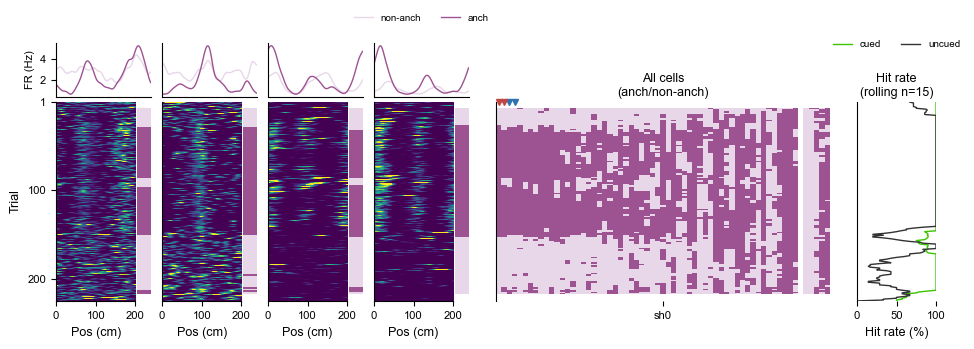

Loading M25D25...
  Computing labels for 108 cells...
  Saved: /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_6_task_anchoring/M25D25_ratemap_anchoring.pdf


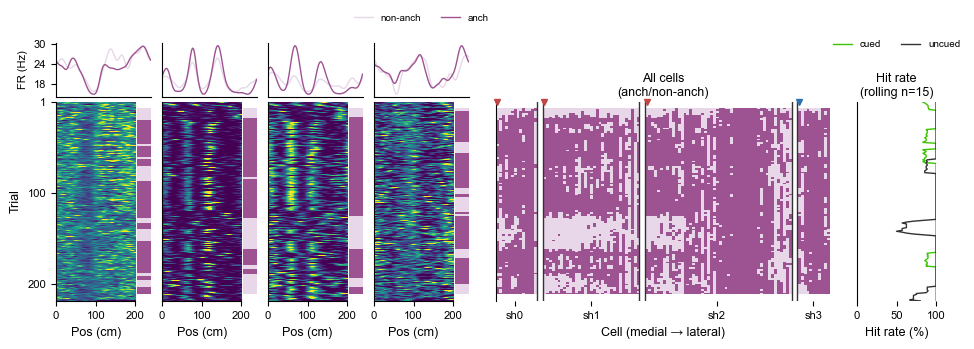

Loading M26D18...
  Computing labels for 50 cells...
  Saved: /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_6_task_anchoring/M26D18_ratemap_anchoring.pdf


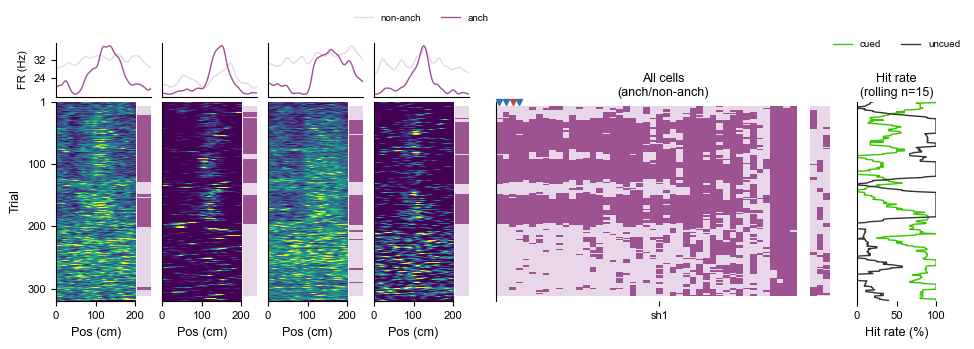

Loading M26D19...
  Computing labels for 280 cells...
  Saved: /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_6_task_anchoring/M26D19_ratemap_anchoring.pdf


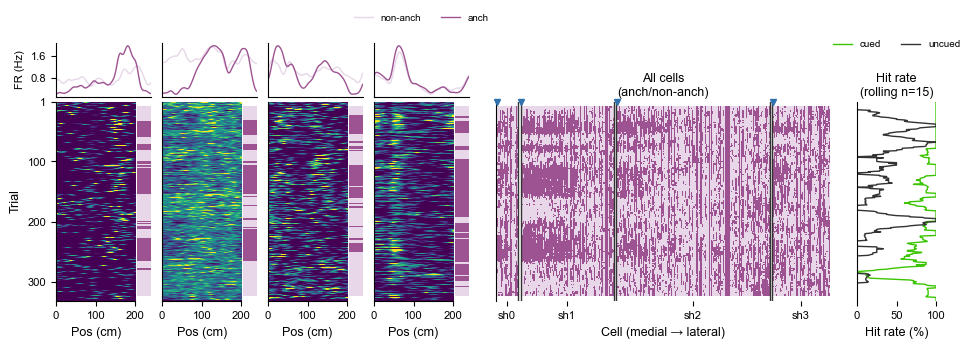

In [5]:
for mouse, day, cell_ids in SESSIONS:
    plot_session(mouse, day, cell_ids=cell_ids)

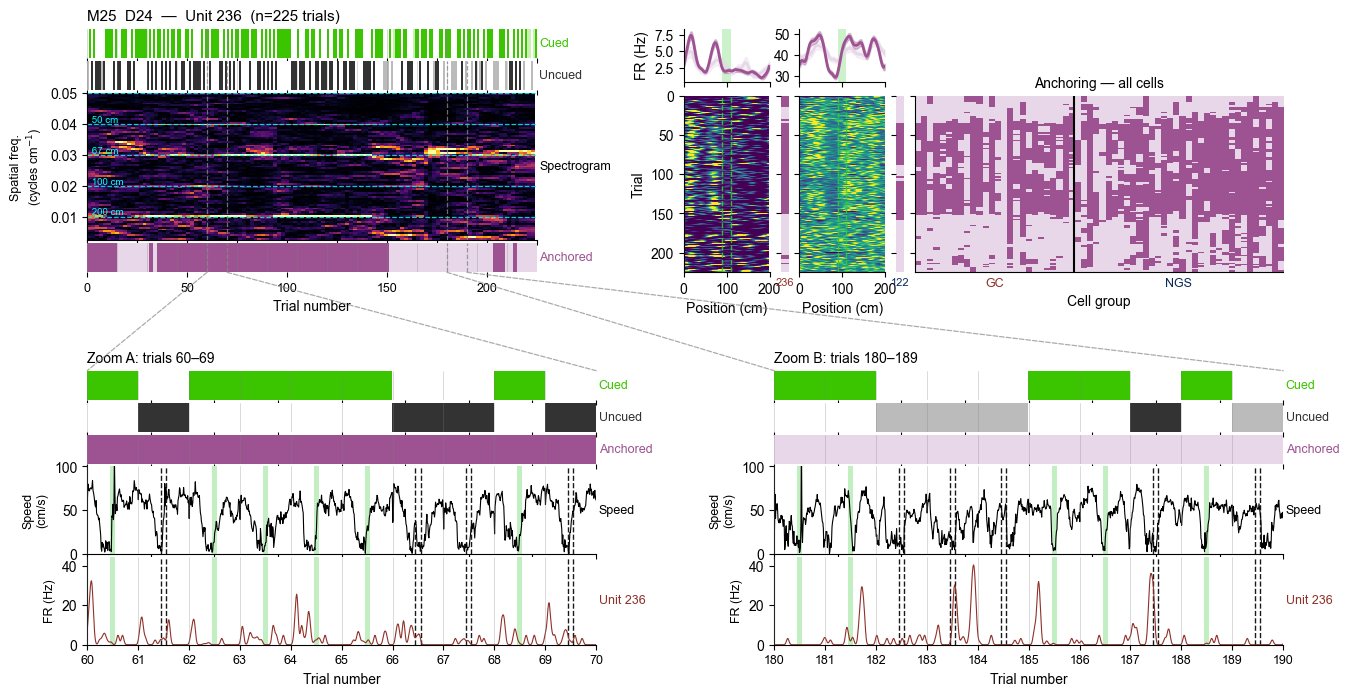

In [6]:
import matplotlib.gridspec as mgridspec
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import ConnectionPatch
import matplotlib.patches as mpatches

# ── Helpers not otherwise defined in this notebook ─────────────────────────────
def make_hit_mask(beh, trial_types):
    """Boolean mask over trials: True where trial type matches AND performance == 'hit'."""
    trials = beh['trials']
    if isinstance(trial_types, (str, int)):
        trial_types = [trial_types]
    type_mask = trials['type'].isin(trial_types)
    hit_mask = trials['performance'] == 'hit'
    return (type_mask & hit_mask).to_numpy()

def make_trialtype_mask(beh, trial_types):
    """Boolean mask over trials: True where trial type matches, regardless of performance."""
    trials = beh['trials']
    if isinstance(trial_types, (str, int)):
        trial_types = [trial_types]
    return trials['type'].isin(trial_types).to_numpy()

# ═══════════════════════════════════════════════════════════════════════════════
EXAMPLE_MOUSE   = 25
EXAMPLE_DAY     = 24
EXAMPLE_CELL    = 236    # GC
EXAMPLE_CELL_2  = 122    # NGS
ZOOM1_START     = 60
ZOOM1_END       = 70
ZOOM2_START     = 180
ZOOM2_END       = 190
# ═══════════════════════════════════════════════════════════════════════════════

COLOR_ANCHOR     = '#9d5391'
COLOR_NON_ANCHOR = '#e7d7e8'
gc_color         = gc_color_dark
ngs_color        = ngs_color_dark
COLOR_B_HIT      = '#3bc500'
COLOR_B_MISS     = '#c8f0b0'
COLOR_NB_HIT     = '#333333'
COLOR_NB_MISS    = '#bbbbbb'
COLOR_SPEED      = 'black'
COLOR_ZOOM_GUIDE = '#888888'
COLOR_RZ         = 'limegreen'

# ── Load ──────────────────────────────────────────────────────────────────────
tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
    EXAMPLE_MOUSE, EXAMPLE_DAY, apply_zscore=False, apply_guassian_filter=False
)
rz_start = 90.0
rz_end   = 110.0
bpt      = int(tl / bs)

# ── Cell 1 (GC) ───────────────────────────────────────────────────────────────
tc1 = gaussian_filter(np.nan_to_num(tcs[EXAMPLE_CELL]).astype(np.float64), sigma=2.5)
tc1 = tc1[:last_ephys_bin]

res1        = spectral_analysis({EXAMPLE_CELL: tc1, 1000: tc1}, tl, bs=bs)
S_cell1     = res1[3][0]
t_spec      = res1[4]
fvalid      = res1[5]
t_dist_spec = t_spec * bs

target_freqs  = np.arange(1, 6) * bs / tl
GRID_FREQ_IDX = [int(np.argmin(np.abs(fvalid - f))) for f in target_freqs]
grid_freqs    = fvalid[GRID_FREQ_IDX]

S_avg1      = res1[3].mean(0)
lbl_idx1    = np.isin(np.argmax(S_avg1, axis=0), GRID_FREQ_IDX).astype(int)
labels_ta1  = get_kmeans_spatial_labels(tc1, lbl_idx1, bs=bs, tl=tl)
n_trials1   = min(len(labels_ta1), len(tc1) // bpt)
labels_ta1  = labels_ta1[:n_trials1]
tc_2d1      = tc1[:n_trials1 * bpt].reshape(n_trials1, bpt)

# ── Cell 2 (NGS) ──────────────────────────────────────────────────────────────
tc2 = gaussian_filter(np.nan_to_num(tcs[EXAMPLE_CELL_2]).astype(np.float64), sigma=2.5)
tc2 = tc2[:last_ephys_bin]

res2        = spectral_analysis({EXAMPLE_CELL_2: tc2, 1000: tc2}, tl, bs=bs)
S_cell2     = res2[3][0]
fvalid2     = res2[5]

GFI2        = [int(np.argmin(np.abs(fvalid2 - f))) for f in target_freqs]
S_avg2      = res2[3].mean(0)
lbl_idx2    = np.isin(np.argmax(S_avg2, axis=0), GFI2).astype(int)
labels_ta2  = get_kmeans_spatial_labels(tc2, lbl_idx2, bs=bs, tl=tl)
n_trials2   = min(len(labels_ta2), len(tc2) // bpt)
labels_ta2  = labels_ta2[:n_trials2]
tc_2d2      = tc2[:n_trials2 * bpt].reshape(n_trials2, bpt)

# common session trial count
n_trials   = min(n_trials1, n_trials2)
labels_ta1 = labels_ta1[:n_trials];  tc_2d1 = tc_2d1[:n_trials]
labels_ta2 = labels_ta2[:n_trials];  tc_2d2 = tc_2d2[:n_trials]

# ── Per-trial signals ─────────────────────────────────────────────────────────
nb_hit_mask  = make_hit_mask(beh, 'nb')
b_hit_mask   = make_hit_mask(beh, 'b')
nb_type_mask = make_trialtype_mask(beh, 'nb')
b_type_mask  = make_trialtype_mask(beh, 'b')

trial_num_arr = np.array(beh['trial_number'])
pos_arr       = np.array(beh['P'])
speed_arr     = np.array(beh['S'])
pos_bins      = np.linspace(0, tl, bpt + 1)

speed_2d = np.full((n_trials, bpt), np.nan)
for t in range(n_trials):
    m = trial_num_arr == (t + 1)
    if not m.any(): continue
    bsums, _ = np.histogram(pos_arr[m], bins=pos_bins, weights=speed_arr[m])
    bcnt,  _ = np.histogram(pos_arr[m], bins=pos_bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        speed_2d[t] = np.where(bcnt > 0, bsums / bcnt, np.nan)

def _make_hit_display(hit_mask, type_mask, n):
    arr = np.zeros(n, dtype=float)
    nt  = min(len(type_mask), len(hit_mask), n)
    arr[:nt] = np.where(type_mask[:nt], np.where(hit_mask[:nt], 2.0, 1.0), 0.0)
    return arr

b_display       = _make_hit_display(b_hit_mask,  b_type_mask,  n_trials)
nb_display      = _make_hit_display(nb_hit_mask, nb_type_mask, n_trials)
anchor_display1 = np.where(np.isnan(labels_ta1.astype(float)), 2.0, labels_ta1.astype(float))
anchor_display2 = np.where(np.isnan(labels_ta2.astype(float)), 2.0, labels_ta2.astype(float))

dist_total   = n_trials * tl
z0_1, z1_1   = max(0, ZOOM1_START), min(n_trials, ZOOM1_END)
z0_2, z1_2   = max(0, ZOOM2_START), min(n_trials, ZOOM2_END)
dist_start_1, dist_end_1 = z0_1 * tl, z1_1 * tl
dist_start_2, dist_end_2 = z0_2 * tl, z1_2 * tl

# ── Anchoring raster for all cells ────────────────────────────────────────────
gcs_df, ngs_df, _ = classify_cells_both_sessions(
    mouse=EXAMPLE_MOUSE, day=EXAMPLE_DAY, percentile_threshold=95, verbose=False
)
gc_ids  = gcs_df.sort_values('grid_score', ascending=False)['cluster_id'].values.tolist()
ngs_ids = ngs_df.sort_values('cluster_id')['cluster_id'].values.tolist()
all_ids = [cid for cid in gc_ids + ngs_ids if cid in tcs]
n_gc    = sum(1 for cid in gc_ids if cid in tcs)
n_cells = len(all_ids)

tc_dict = {cid: gaussian_filter(np.nan_to_num(tcs[cid]).astype(np.float64), sigma=2.5)[:last_ephys_bin]
           for cid in all_ids}

res_batch = spectral_analysis(tc_dict, tl, bs=bs)
Sxs_batch = res_batch[3]
fvalid_b  = res_batch[5]
gfi_b     = [int(np.argmin(np.abs(fvalid_b - f))) for f in target_freqs]

raster_arr = np.full((n_cells, n_trials), 2.0)
for i, cid in enumerate(all_ids):
    tc_c  = tc_dict[cid]
    li_c  = np.isin(np.argmax(Sxs_batch[i], axis=0), gfi_b).astype(int)
    lab_c = get_kmeans_spatial_labels(tc_c, li_c, bs=bs, tl=tl)
    nt_c  = min(len(lab_c), len(tc_c) // bpt, n_trials)
    raster_arr[i, :nt_c] = np.where(
        np.isnan(lab_c[:nt_c].astype(float)), 2.0, lab_c[:nt_c].astype(float)
    )

# ── Colour maps ───────────────────────────────────────────────────────────────
b_cmap      = ListedColormap(['white', COLOR_B_MISS,     COLOR_B_HIT])
nb_cmap     = ListedColormap(['white', COLOR_NB_MISS,    COLOR_NB_HIT])
hit_norm    = BoundaryNorm([0, 0.5, 1.5, 2.5], 3)
anchor_cmap = ListedColormap([COLOR_NON_ANCHOR, COLOR_ANCHOR, 'white'])
anchor_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], 3)

# ── Layout ────────────────────────────────────────────────────────────────────
STRIP = 0.4
SPEC  = 2.0
LINE  = 1.2

H_FULL = [STRIP, STRIP, SPEC, STRIP]
H_ZOOM = [STRIP, STRIP, STRIP, LINE, LINE]

fig = plt.figure(figsize=(13, 7))

gs_master = mgridspec.GridSpec(
    2, 1, figure=fig,
    height_ratios=[sum(H_FULL), sum(H_ZOOM)],
    hspace=0.38,
    left=0.05, right=0.97, top=0.95, bottom=0.07,
)

gs_top = mgridspec.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=gs_master[0], width_ratios=[3, 4.0], wspace=0.28,
)

gs_right = mgridspec.GridSpecFromSubplotSpec(
    2, 5, subplot_spec=gs_top[1],
    height_ratios=[0.3, 1],
    width_ratios=[0.7, 0.06, 0.7, 0.06, 3.0],
    wspace=0.10, hspace=0.12,
)
ax_C1   = fig.add_subplot(gs_right[0, 0])
ax_rm1  = fig.add_subplot(gs_right[1, 0])
ax_a1   = fig.add_subplot(gs_right[1, 1])
ax_C2   = fig.add_subplot(gs_right[0, 2])
ax_rm2  = fig.add_subplot(gs_right[1, 2])
ax_a2   = fig.add_subplot(gs_right[1, 3])
ax_R    = fig.add_subplot(gs_right[1, 4])

ax_C1.sharex(ax_rm1)
ax_C2.sharex(ax_rm2)
ax_rm1.sharex(ax_rm2)

gs_bot   = mgridspec.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=gs_master[1], width_ratios=[1, 1], wspace=0.35,
)
gs_full  = mgridspec.GridSpecFromSubplotSpec(4, 1, subplot_spec=gs_top[0],  height_ratios=H_FULL, hspace=0.05)
gs_zoom1 = mgridspec.GridSpecFromSubplotSpec(5, 1, subplot_spec=gs_bot[0],  height_ratios=H_ZOOM, hspace=0.05)
gs_zoom2 = mgridspec.GridSpecFromSubplotSpec(5, 1, subplot_spec=gs_bot[1],  height_ratios=H_ZOOM, hspace=0.05)

ax_F  = [fig.add_subplot(gs_full[i])  for i in range(4)]
ax_Z1 = [fig.add_subplot(gs_zoom1[i]) for i in range(5)]
ax_Z2 = [fig.add_subplot(gs_zoom2[i]) for i in range(5)]


# ── Helpers ───────────────────────────────────────────────────────────────────
def _strip(ax, data, cmap, norm, d0, d1, tl, row_label, label_color='k'):
    t0, t1 = int(round(d0 / tl)), int(round(d1 / tl))
    arr = data[t0:t1]
    ax.imshow(arr[np.newaxis, :], aspect='auto', cmap=cmap, norm=norm,
              interpolation='nearest', extent=[d0, d1, 0.5, -0.5], origin='upper')
    ax.set_yticks([])
    ax.set_xlim(d0, d1)
    for s in ax.spines.values(): s.set_visible(False)
    ax.text(1.005, 0.5, row_label, transform=ax.transAxes,
            ha='left', va='center', fontsize=9, color=label_color)

def _spectrogram(ax, S, t_dist, fvalid, grid_freqs, d0, d1):
    dt = t_dist[1] - t_dist[0]
    win_mask = (t_dist >= d0 - dt) & (t_dist <= d1 + dt)
    if win_mask.sum() < 2: return
    t_sel = t_dist[win_mask]
    S_sel = S[:, win_mask]
    vmax  = float(np.percentile(S_sel, 99))
    ax.imshow(S_sel, aspect='auto', origin='lower',
              extent=[t_sel[0], t_sel[-1], fvalid[0], fvalid[-1]],
              cmap='inferno', interpolation='nearest', vmin=0, vmax=vmax)
    for gf in grid_freqs:
        ax.axhline(gf, color='cyan', linewidth=0.9, linestyle='--', alpha=0.8)
        ax.text(d0 + (d1 - d0) * 0.005, gf, f' {bs/gf:.0f} cm',
                color='cyan', fontsize=7, va='bottom', clip_on=True)
    ax.set_ylabel('Spatial freq.\n(cycles cm$^{-1}$)', fontsize=9)

    ax.set_xlim(d0, d1)
    ax.set_ylim(fvalid[0], fvalid[-1])
    for s in ['top', 'right']: ax.spines[s].set_visible(False)
    ax.text(1.005, 0.5, 'Spectrogram', transform=ax.transAxes,
            ha='left', va='center', fontsize=9)

def _vlines(axes, t_start, t_end, tl, d0, d1, every=1):
    for t in range(t_start, t_end + 1, every):
        for a in axes:
            a.axvline(t * tl, color='gray', linewidth=0.4, alpha=0.5, zorder=3)
    for a in axes:
        a.set_xlim(d0, d1)

def _trial_ticks(ax, tick_trials, tl):
    ax.set_xticks(tick_trials * tl)
    ax.set_xticklabels([str(t) for t in tick_trials], fontsize=9)
    ax.set_xlabel('Trial number', fontsize=10)

def _rz_marks(axes, z0, n_zoom, tl, rz_start, rz_end):
    for t_off in range(n_zoom):
        t_abs = z0 + t_off
        x0 = t_abs * tl + rz_start
        x1 = t_abs * tl + rz_end
        is_b  = (t_abs < len(b_type_mask))  and bool(b_type_mask[t_abs])
        is_nb = (t_abs < len(nb_type_mask)) and bool(nb_type_mask[t_abs])
        for a in axes:
            if is_b:
                a.axvspan(x0, x1, color=COLOR_RZ, alpha=0.3, zorder=1, linewidth=0)
            elif is_nb:
                a.axvline(x0, color='black', linewidth=1.0, linestyle='--', alpha=0.9, zorder=1)
                a.axvline(x1, color='black', linewidth=1.0, linestyle='--', alpha=0.9, zorder=1)

def _draw_zoom(ax_Z, z0, z1, title):
    n_zoom = z1 - z0
    d0, d1 = z0 * tl, z1 * tl
    for a in ax_Z[:-1]: a.tick_params(labelbottom=False)
    _strip(ax_Z[0], b_display,       b_cmap,      hit_norm,    d0, d1, tl, 'Cued',     COLOR_B_HIT)
    _strip(ax_Z[1], nb_display,      nb_cmap,     hit_norm,    d0, d1, tl, 'Uncued',   COLOR_NB_HIT)
    _strip(ax_Z[2], anchor_display1, anchor_cmap, anchor_norm, d0, d1, tl, 'Anchored', COLOR_ANCHOR)
    ax_Z[0].set_title(title, fontsize=10, loc='left')
    ax_sp, ax_fr = ax_Z[3], ax_Z[4]
    x_dist = np.array(
        [(z0 + t_off) * tl + (pos_i + 0.5) * bs
         for t_off in range(n_zoom) for pos_i in range(bpt)]
    )
    _rz_marks([ax_sp, ax_fr], z0, n_zoom, tl, rz_start, rz_end)
    ax_sp.plot(x_dist, speed_2d[z0:z1, :].ravel(), color=COLOR_SPEED, linewidth=0.8)
    ax_sp.set_ylabel('Speed\n(cm/s)', fontsize=9)
    ax_sp.text(1.005, 0.5, 'Speed', transform=ax_sp.transAxes,
               ha='left', va='center', fontsize=9, color=COLOR_SPEED)
    for s in ['top', 'right']: ax_sp.spines[s].set_visible(False)
    ax_fr.plot(x_dist, tc_2d1[z0:z1, :].ravel(), color=gc_color, linewidth=0.8)
    ax_fr.set_ylabel('FR (Hz)', fontsize=9)
    ax_fr.set_ylim(bottom=0)
    ax_fr.text(1.005, 0.5, f'Unit {EXAMPLE_CELL}',
               transform=ax_fr.transAxes, ha='left', va='center', fontsize=9, color=gc_color)
    for s in ['top', 'right']: ax_fr.spines[s].set_visible(False)
    _vlines([ax_Z[0], ax_Z[1], ax_Z[2], ax_sp, ax_fr], z0, z1, tl, d0, d1)
    _trial_ticks(ax_fr, np.arange(z0, z1 + 1), tl)
    for a in ax_Z: a.set_xlim(d0, d1)
    return ax_sp, ax_fr

def _avg_fr_panel(ax, tc_2d, labels_ta, cell_id, color, title):
    x_pos = np.arange(bs / 2, tl + bs / 2, bs)
    ax.axvspan(rz_start, rz_end, color=COLOR_RZ, alpha=0.25, zorder=0, linewidth=0)
    for label_val, lcolor, lbl in [
        (0, COLOR_NON_ANCHOR, 'Non-anchored'),
        (1, COLOR_ANCHOR,     'Anchored'),
    ]:
        mask = labels_ta == label_val
        if mask.sum() > 5:
            avg_fr = np.nanmean(tc_2d[mask, :], axis=0)
            sem_fr = np.nanstd(tc_2d[mask, :], axis=0) / np.sqrt(mask.sum())
            ax.fill_between(x_pos, avg_fr - sem_fr, avg_fr + sem_fr, color=lcolor, alpha=0.35)
            ax.plot(x_pos, avg_fr, color=lcolor, linewidth=2, label=f'{lbl} (n={mask.sum()})')
    ax.tick_params(labelbottom=False)
    ax.set_ylabel('FR (Hz)', fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.set_xlim(0, tl)
    for s in ['top', 'right']: ax.spines[s].set_visible(False)

def _rate_map_panel(ax, tc, bpt, n_trials, color, xlabel=True):
    plot_firing_rate_map(ax, tc[:n_trials * bpt], bs=bs, tl=tl, p=95,
                         sort_indices=None, cmap='viridis')
    ax.axvline(rz_start, color=COLOR_RZ, linewidth=1.0, linestyle='--', alpha=0.9)
    ax.axvline(rz_end,   color=COLOR_RZ, linewidth=1.0, linestyle='--', alpha=0.9)
    if xlabel:
        ax.set_xlabel('Position (cm)', fontsize=10)
    ax.set_xlim(0, tl)
    for s in ['top', 'right']: ax.spines[s].set_visible(False)

def _anchor_strip(ax, anchor_display, n_trials, cell_id, cell_color):
    ax.imshow(
        anchor_display[:n_trials, np.newaxis],
        aspect='auto', cmap=anchor_cmap, norm=anchor_norm,
        extent=[-0.5, 0.5, n_trials, 0],
        interpolation='nearest', origin='upper',
    )
    ax.set_xlim(-0.5, 0.5)
    ax.set_xticks([])
    ax.tick_params(labelleft=False)
    ax.set_xlabel(f'{cell_id}', fontsize=8, color=cell_color)
    for s in ax.spines.values(): s.set_visible(False)


# ── Full-session panel ────────────────────────────────────────────────────────
for a in ax_F[:-1]: a.tick_params(labelbottom=False)

_strip(ax_F[0], b_display,       b_cmap,      hit_norm,    0, dist_total, tl, 'Cued',     COLOR_B_HIT)
_strip(ax_F[1], nb_display,      nb_cmap,     hit_norm,    0, dist_total, tl, 'Uncued',   COLOR_NB_HIT)
_spectrogram(ax_F[2], S_cell1, t_dist_spec, fvalid, grid_freqs, 0, dist_total)
_strip(ax_F[3], anchor_display1, anchor_cmap, anchor_norm, 0, dist_total, tl, 'Anchored', COLOR_ANCHOR)

ax_F[0].set_title(
    f'M{EXAMPLE_MOUSE}  D{EXAMPLE_DAY}  —  Unit {EXAMPLE_CELL}  (n={n_trials} trials)',
    fontsize=11, loc='left'
)

for dist_x in [dist_start_1, dist_end_1, dist_start_2, dist_end_2]:
    for a in ax_F:
        a.axvline(dist_x, color=COLOR_ZOOM_GUIDE, linestyle='--',
                  linewidth=0.9, alpha=0.8, zorder=5)

every_n = max(5, n_trials // 15)
_vlines([ax_F[0], ax_F[1], ax_F[3]], 0, n_trials, tl, 0, dist_total, every=every_n)
_trial_ticks(ax_F[3], np.arange(0, n_trials + 1, 50), tl)
for a in ax_F: a.set_xlim(0, dist_total)


# ── Zoom panels ───────────────────────────────────────────────────────────────
ax_sp1, ax_fr1 = _draw_zoom(ax_Z1, z0_1, z1_1, f'Zoom A: trials {z0_1}–{z1_1-1}')
ax_sp2, ax_fr2 = _draw_zoom(ax_Z2, z0_2, z1_2, f'Zoom B: trials {z0_2}–{z1_2-1}')

for ax in [ax_sp1, ax_sp2]: ax.set_ylim(0, 100)
fr_max = max(np.nanmax(tc_2d1[z0_1:z1_1]), np.nanmax(tc_2d1[z0_2:z1_2]))
for ax in [ax_fr1, ax_fr2]: ax.set_ylim(0, fr_max * 1.1)


# ── Connecting lines ──────────────────────────────────────────────────────────
for (d_s, d_e), ax_Z in [((dist_start_1, dist_end_1), ax_Z1),
                           ((dist_start_2, dist_end_2), ax_Z2)]:
    for xy_top, xy_bot in [
        ((d_s / dist_total, 0.0), (0.0, 1.0)),
        ((d_e / dist_total, 0.0), (1.0, 1.0)),
    ]:
        fig.add_artist(ConnectionPatch(
            xyA=xy_top, coordsA='axes fraction', axesA=ax_F[3],
            xyB=xy_bot, coordsB='axes fraction', axesB=ax_Z[0],
            color=COLOR_ZOOM_GUIDE, linestyle='--', linewidth=0.9,
            alpha=0.7, clip_on=False, zorder=10,
        ))


# ── Cell 1 panels (GC) ───────────────────────────────────────────────────────
_avg_fr_panel(ax_C1, tc_2d1, labels_ta1, EXAMPLE_CELL,
              gc_color, f'')
_rate_map_panel(ax_rm1, tc1, bpt, n_trials, gc_color, xlabel=True)
ax_rm1.set_ylabel('Trial', fontsize=10)
_anchor_strip(ax_a1, anchor_display1, n_trials, EXAMPLE_CELL, gc_color)


# ── Cell 2 panels (NGS) ──────────────────────────────────────────────────────
_avg_fr_panel(ax_C2, tc_2d2, labels_ta2, EXAMPLE_CELL_2,
              ngs_color, f'')
_rate_map_panel(ax_rm2, tc2, bpt, n_trials, ngs_color, xlabel=True)
ax_rm2.tick_params(labelleft=False)
_anchor_strip(ax_a2, anchor_display2, n_trials, EXAMPLE_CELL_2, ngs_color)
ax_C2.set_ylabel('')

# ── All-cells raster ──────────────────────────────────────────────────────────
ax_R.imshow(
    raster_arr.T,
    aspect='auto', cmap=anchor_cmap, norm=anchor_norm,
    extent=[-0.5, n_cells - 0.5, n_trials, 0],
    interpolation='nearest', origin='upper',
)
ax_R.axvline(n_gc - 0.5, color='black', linewidth=1.5)
ax_R.tick_params(labelleft=False)
ax_R.set_xlim(-0.5, n_cells - 0.5)
ax_R.set_xticks([n_gc / 2 - 0.5, n_gc + (n_cells - n_gc) / 2 - 0.5])
ax_R.set_xticklabels(['GC', 'NGS'], fontsize=9)
ax_R.tick_params(axis='x', length=0)
ax_R.xaxis.get_ticklabels()[0].set_color(gc_color)
ax_R.xaxis.get_ticklabels()[1].set_color(ngs_color)
ax_R.set_xlabel('Cell group', fontsize=10)
ax_R.set_title('Anchoring — all cells', fontsize=10)
for s in ['top', 'right']: ax_R.spines[s].set_visible(False)

y_top, y_bot = n_trials, 0
for ax in [ax_rm1, ax_a1, ax_rm2, ax_a2, ax_R]:
    ax.set_ylim(y_top, y_bot)


fname = os.path.join(OUT_DIR, f'M{EXAMPLE_MOUSE}D{EXAMPLE_DAY}_unit{EXAMPLE_CELL}_spectrogram_overview.pdf')
plt.savefig(fname, dpi=300, bbox_inches='tight')
fname = os.path.join(OUT_DIR, f'M{EXAMPLE_MOUSE}D{EXAMPLE_DAY}_unit{EXAMPLE_CELL}_spectrogram_overview.png')
plt.savefig(fname, dpi=500, bbox_inches='tight')
plt.show()

Loading M25D24...
  Computing labels for 63 cells...
  Saved: /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_6_task_anchoring/M25D24_ratemap_anchoring_scy.pdf


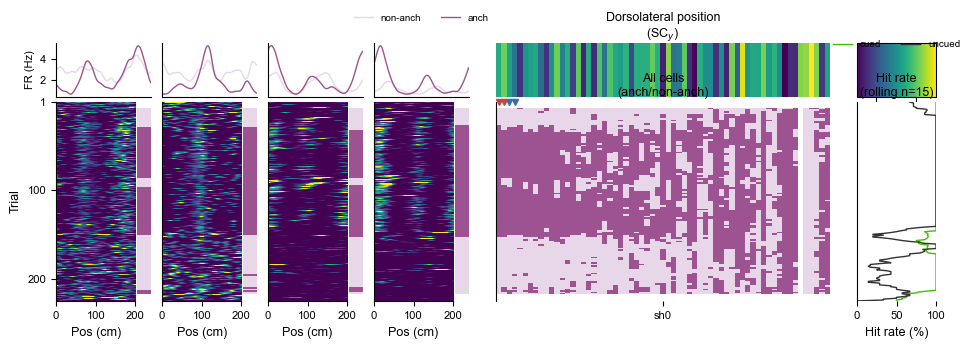

Loading M25D25...
  Computing labels for 108 cells...
  Saved: /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_6_task_anchoring/M25D25_ratemap_anchoring_scy.pdf


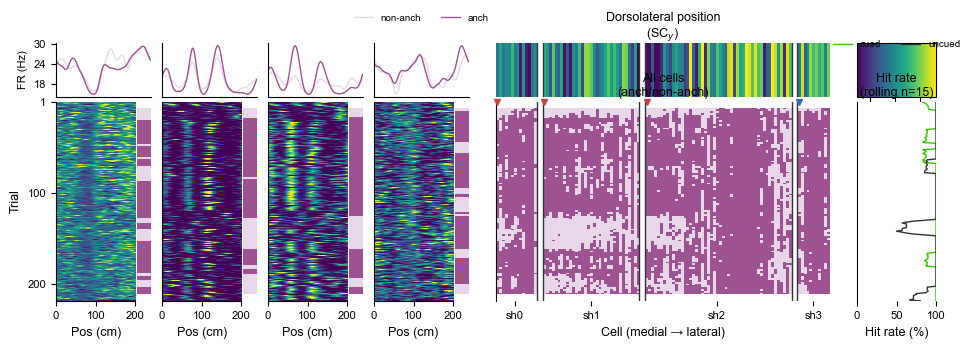

Loading M26D18...
  Computing labels for 50 cells...
  Saved: /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_6_task_anchoring/M26D18_ratemap_anchoring_scy.pdf


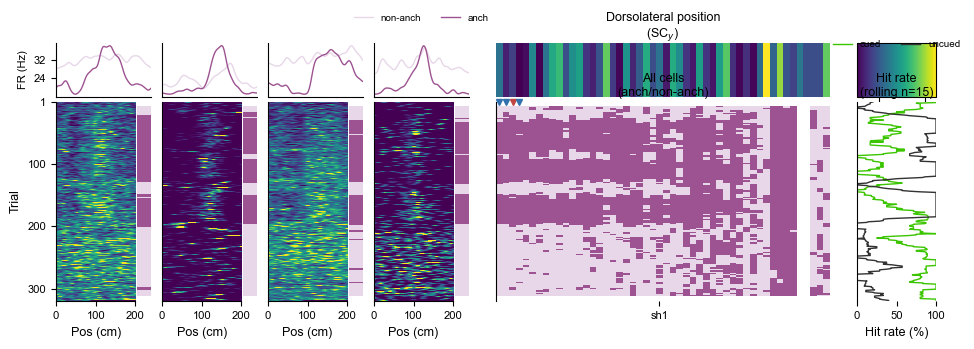

Loading M26D19...
  Computing labels for 280 cells...
  Saved: /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_6_task_anchoring/M26D19_ratemap_anchoring_scy.pdf


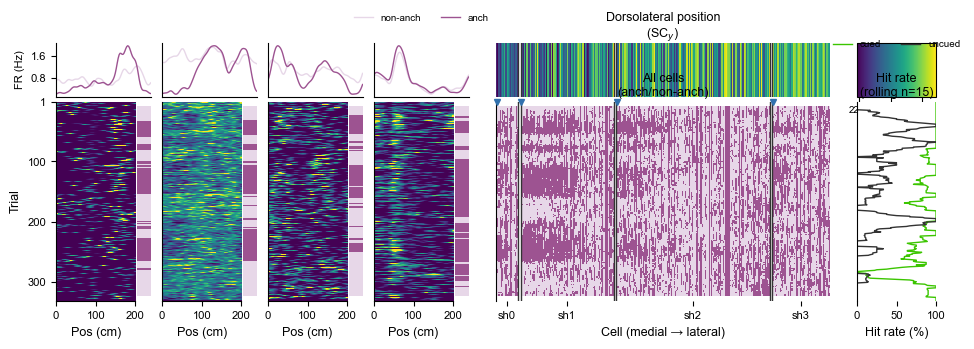

In [7]:
def plot_session_with_scy_strip(mouse, day, cell_ids=None, source_path=SOURCE_PATH,
               out_dir=OUT_DIR):
    """Same figure as plot_session, plus a colorstrip just above the population
    anchoring raster showing each cell's dorsolateral position (SC_y), aligned
    column-for-column (and shank-grouped) with the raster below it."""
    print(f'Loading M{mouse}D{day}...')
    try:
        gcs, ngs, all_cells = classify_cells_both_sessions(
            mouse=mouse, day=day, percentile_threshold=95,
            verbose=False, source_path=source_path)
        tcs, _, _, last_ephys_bin, beh, _ = compute_vr_tcs(
            mouse, day, apply_zscore=False, apply_guassian_filter=False,
            source_path=source_path)
    except Exception as e:
        print(f'  Error loading M{mouse}D{day}: {e}'); return

    gc_ids  = set(gcs['cluster_id'].astype(int))
    ngs_ids = set(ngs['cluster_id'].astype(int))

    all_cells = all_cells.copy()
    all_cells['_abs_sc_x'] = np.abs(all_cells['SC_x'])
    all_cells = all_cells.sort_values('_abs_sc_x').reset_index(drop=True)
    valid_ids = [int(cid) for cid in all_cells['cluster_id'] if int(cid) in tcs]

    _locs = pd.read_csv(f'{source_path}/all_cluster_brain_locations_chris.csv')
    _locs = _locs[(_locs['mouse'] == mouse) & (_locs['day'] == day)]
    def _keep_region(cid):
        row = _locs[_locs['cluster_id'] == cid]
        if row.empty: return False
        return any(str(row['brain_region'].values[0]).upper().startswith(r) for r in REGIONS_KEEP)
    valid_ids = [cid for cid in valid_ids if _keep_region(cid)]
    if not valid_ids:
        print(f'  No {REGIONS_KEEP} cells for M{mouse}D{day}'); return

    order_map = {int(cid): i for i, cid in enumerate(all_cells['cluster_id'])}
    sc_x_map  = dict(zip(all_cells['cluster_id'].astype(int), all_cells['SC_x']))
    sc_y_map  = dict(zip(all_cells['cluster_id'].astype(int), all_cells['SC_y']))

    print(f'  Computing labels for {len(valid_ids)} cells...')
    all_cells_sh = reconstruct_shank_id(all_cells, mouse, colname='probe_x')
    shank_map    = dict(zip(all_cells_sh['cluster_id'].astype(int),
                            all_cells_sh['shank_id']))

    all_labels   = []
    n_trials_ref = None
    for cid in valid_ids:
        try:
            _, labels, n_t = _compute_tc_and_labels(cid, tcs, last_ephys_bin)
            if n_trials_ref is None: n_trials_ref = n_t
            all_labels.append((cid, labels[:n_trials_ref], shank_map.get(cid, -1)))
        except Exception:
            pass
    if n_trials_ref is None:
        print('  Could not compute any labels'); return

    if cell_ids is None:
        chosen = _select_by_pc1(all_labels, n_select=N_RANDOM)
    else:
        chosen = [c for c in cell_ids if c in tcs]
    chosen = sorted(chosen, key=lambda c: order_map.get(c, 9999))
    if not chosen:
        print(f'  No valid cells for M{mouse}D{day}'); return

    N = len(chosen)
    chosen_labels = {cid: lab for cid, lab, _ in all_labels if cid in set(chosen)}

    all_labels = _sort_within_shanks_by_pc1(all_labels)

    # ── Transposed population matrix ──────────────────────────────────────────
    pop_cols       = []
    shank_col_divs = []
    real_col_map   = {}
    prev_shank = None
    for cid, lab, sh in all_labels:
        if prev_shank is not None and sh != prev_shank:
            shank_col_divs.append(len(pop_cols))
            for _ in range(GAP_COLS): pop_cols.append(None)
        real_col_map[cid] = len(pop_cols)
        pop_cols.append((cid, lab))
        prev_shank = sh

    n_pop_cols = len(pop_cols)
    pop_matrix = np.full((n_trials_ref, n_pop_cols), np.nan)
    for ci, entry in enumerate(pop_cols):
        if entry is not None:
            cid, lab = entry
            n = min(len(lab), n_trials_ref)
            pop_matrix[:n, ci] = lab[:n]

    # ── SC_y (dorsolateral position) per population-raster column ─────────────
    scy_row = np.full(n_pop_cols, np.nan)
    for ci, entry in enumerate(pop_cols):
        if entry is not None:
            cid, _ = entry
            scy_row[ci] = sc_y_map.get(cid, np.nan)

    # ── Rolling hit rate ──────────────────────────────────────────────────────
    trial_types = np.array(beh['trials']['type'])[:n_trials_ref]
    is_hit      = (np.array(beh['trials']['performance']) == 'hit')[:n_trials_ref]
    b_mask      = trial_types == 'b'
    nb_mask     = trial_types == 'nb'
    ROLL_WIN    = 15
    kernel      = np.ones(ROLL_WIN) / ROLL_WIN

    def _roll(type_mask):
        num = np.convolve((type_mask & is_hit).astype(float), kernel, mode='same')
        den = np.convolve(type_mask.astype(float),            kernel, mode='same')
        return np.where(den > 0, num / den * 100, np.nan)

    b_roll     = _roll(b_mask)
    nb_roll    = _roll(nb_mask)
    trial_axis = np.arange(n_trials_ref)

    # ── Layout ────────────────────────────────────────────────────────────────
    RM_W_INCH    = 2.0
    RA_W_INCH    = 0.35
    CELL_W_INCH  = RM_W_INCH + RA_W_INCH
    HIT_W_INCH   = 1.8
    TOTAL_LEFT_W = N * CELL_W_INCH
    POP_W_INCH   = TOTAL_LEFT_W - HIT_W_INCH
    AVG_H_INCH   = 1.2
    RM_H_INCH    = 4.5

    fig = plt.figure(figsize=(10, 3))

    gs_outer = gridspec.GridSpec(
        2, 3,
        height_ratios=[AVG_H_INCH, RM_H_INCH],
        width_ratios=[TOTAL_LEFT_W, POP_W_INCH, HIT_W_INCH],
        hspace=0.04, wspace=0.10,
        left=0.09, right=0.97, top=0.95, bottom=0.09
    )

    gs_left = gridspec.GridSpecFromSubplotSpec(
        2, N,
        subplot_spec=gs_outer[:, 0],
        height_ratios=[AVG_H_INCH, RM_H_INCH],
        hspace=0.04, wspace=0.12
    )

    # gs_outer[0, 1] and gs_outer[0, 2] are otherwise unused (blank margin above
    # ax_pop / ax_hit) -- reuse them for the SC_y colorstrip + its colorbar.
    ax_scy      = fig.add_subplot(gs_outer[0, 1])
    ax_scy_cbar = fig.add_subplot(gs_outer[0, 2])
    ax_pop = fig.add_subplot(gs_outer[1, 1])
    ax_hit = fig.add_subplot(gs_outer[1, 2])

    y_top = -0.5
    y_bot = n_trials_ref - 0.5

    # ── Y-tick positions: 1, 100, 200 … ──────────────────────────────────────
    tick_labels = np.concatenate([[1], np.arange(100, n_trials_ref + 1, 100)])
    tick_pos    = tick_labels - 1   # 0-indexed centres in imshow coords

    # ── Rate maps + avg FR + individual cell rasters ──────────────────────────
    for col_i, cid in enumerate(chosen):
        ax_avg = fig.add_subplot(gs_left[0, col_i])

        gs_cell = gridspec.GridSpecFromSubplotSpec(
            1, 2,
            subplot_spec=gs_left[1, col_i],
            width_ratios=[RM_W_INCH, RA_W_INCH],
            wspace=0.03
        )
        ax_rm = fig.add_subplot(gs_cell[0, 0])
        ax_ra = fig.add_subplot(gs_cell[0, 1])

        tc_2d, labels, n_trials = _compute_tc_and_labels(cid, tcs, last_ephys_bin)
        n_use   = min(n_trials, n_trials_ref)
        vmax    = float(np.nanpercentile(tc_2d, 99)) or 1.0
        lab_use = chosen_labels.get(cid, labels)[:n_use]

        anch_idx    = np.where(lab_use == 1)[0]
        nonanch_idx = np.where(lab_use == 0)[0]
        pos_axis    = np.linspace(0, tl, bpt)
        mean_anch    = np.nanmean(tc_2d[anch_idx],    axis=0) if len(anch_idx)    > 0 else np.zeros(bpt)
        mean_nonanch = np.nanmean(tc_2d[nonanch_idx], axis=0) if len(nonanch_idx) > 0 else np.zeros(bpt)

        ax_avg.plot(pos_axis, mean_nonanch, color='#e7d7e8', lw=1.0, label='non-anch')
        ax_avg.plot(pos_axis, mean_anch,    color='#9d5391', lw=1.0, label='anch')
        ax_avg.set_xlim(0, tl)
        ax_avg.tick_params(bottom=False, labelbottom=False, labelsize=8)
        ax_avg.yaxis.set_major_locator(plt.MaxNLocator(3, integer=False))
        for sp in ax_avg.spines.values(): sp.set_visible(False)
        ax_avg.spines['bottom'].set_visible(True)
        ax_avg.spines['left'].set_visible(True)
        if col_i == 0:
            ax_avg.set_ylabel('FR (Hz)', fontsize=8)
        else:
            ax_avg.set_yticks([])
        if col_i == N - 1:
            ax_avg.legend(fontsize=7, loc='lower center', bbox_to_anchor=(0.5, 1.22),
                          frameon=False, ncol=2)

        ctype    = _cell_type(cid, gc_ids, ngs_ids)
        color    = _cell_color(ctype)

        # Rate map
        ax_rm.imshow(tc_2d[:n_use], aspect='auto', cmap='viridis',
                     interpolation='nearest', origin='upper',
                     extent=[0, tl, n_use - 0.5, -0.5],
                     vmin=0, vmax=vmax)
        for sp in ax_rm.spines.values(): sp.set_visible(False)
        ax_rm.spines['left'].set_visible(True)
        ax_rm.spines['bottom'].set_visible(True)
        ax_rm.set_xlabel('Pos (cm)', fontsize=9)
        ax_rm.set_xticks([0, tl // 2, tl])
        ax_rm.set_xticklabels([0, tl // 2, tl], fontsize=8)
        ax_rm.set_ylim(y_bot, y_top)
        if col_i == 0:
            ax_rm.set_yticks(tick_pos[tick_pos < n_use])
            ax_rm.set_yticklabels(tick_labels[tick_pos < n_use], fontsize=8)
            ax_rm.set_ylabel('Trial', fontsize=9)
        else:
            ax_rm.set_yticks([])

        # Individual cell anchoring raster — no bottom spine
        cell_raster = np.full((n_trials_ref, 1), np.nan)
        cell_raster[:n_use, 0] = lab_use
        ax_ra.imshow(cell_raster, aspect='auto', cmap=CMAP_TA, norm=NORM_TA,
                     interpolation='nearest', origin='upper',
                     extent=[-0.5, 0.5, y_bot, y_top])
        ax_ra.set_xlim(-0.5, 0.5)
        ax_ra.set_ylim(y_bot, y_top)
        ax_ra.set_xticks([])
        ax_ra.set_yticks([])
        for sp in ax_ra.spines.values(): sp.set_visible(False)

    # ── SC_y colorstrip (dorsolateral position), shank-grouped like ax_pop ────
    scy_finite = scy_row[~np.isnan(scy_row)]
    vmin_scy = float(np.nanmin(scy_row)) if scy_finite.size else 0.0
    vmax_scy = float(np.nanmax(scy_row)) if scy_finite.size else 1.0
    im_scy = ax_scy.imshow(
        scy_row[np.newaxis, :], aspect='auto', cmap='viridis',
        vmin=vmin_scy, vmax=vmax_scy,
        extent=[-0.5, n_pop_cols - 0.5, 0, 1],
        interpolation='nearest', origin='upper',
    )
    for div in shank_col_divs:
        ax_scy.axvline(div - 0.5,            color='#333333', lw=1.0)
        ax_scy.axvline(div + GAP_COLS - 0.5, color='#333333', lw=1.0)
    ax_scy.set_xlim(-0.5, n_pop_cols - 0.5)
    ax_scy.set_xticks([])
    ax_scy.set_yticks([])
    for sp in ax_scy.spines.values(): sp.set_visible(False)
    ax_scy.set_title('Dorsolateral position\n(SC$_y$)', fontsize=9, pad=4)

    cbar = fig.colorbar(im_scy, cax=ax_scy_cbar, orientation='horizontal')
    cbar.ax.tick_params(labelsize=7)
    cbar.set_label('SC$_y$', fontsize=8)

    # ── Population raster ─────────────────────────────────────────────────────
    ax_pop.imshow(pop_matrix, aspect='auto', cmap=CMAP_TA, norm=NORM_TA,
                  interpolation='nearest', origin='upper',
                  extent=[-0.5, n_pop_cols - 0.5, y_bot, y_top])
    for div in shank_col_divs:
        ax_pop.axvline(div - 0.5,            color='#333333', lw=1.0)
        ax_pop.axvline(div + GAP_COLS - 0.5, color='#333333', lw=1.0)
    for cid in chosen:
        if cid in real_col_map:
            ax_pop.plot(real_col_map[cid], y_top, marker='v',
                        color=_cell_color(_cell_type(cid, gc_ids, ngs_ids)),
                        markersize=5, clip_on=False, zorder=5, linestyle='none')
    shank_cols_by_id = {}
    for cid, lab, sh in all_labels:
        shank_cols_by_id.setdefault(sh, []).append(real_col_map[cid])
    ax_pop.set_xticks([int(np.mean(c)) for c in shank_cols_by_id.values()])
    ax_pop.set_xticklabels([f'sh{sh}' for sh in shank_cols_by_id], fontsize=8)
    if len(shank_cols_by_id) > 1:
        ax_pop.set_xlabel('Cell (medial → lateral)', fontsize=9)
    ax_pop.set_xlim(-0.5, n_pop_cols - 0.5)
    ax_pop.set_ylim(y_bot, y_top)
    ax_pop.set_yticks([])
    ax_pop.yaxis.tick_right()
    for sp in ax_pop.spines.values(): sp.set_visible(False)
    ax_pop.spines['left'].set_visible(True)
    ax_pop.set_title('All cells\n(anch/non-anch)', fontsize=9, pad=4)

    # ── Rolling hit rate ──────────────────────────────────────────────────────
    ax_hit.plot(b_roll,  trial_axis, color='#3bc500', lw=1.0, label='cued')
    ax_hit.plot(nb_roll, trial_axis, color='#333333', lw=1.0, label='uncued')
    ax_hit.set_xlim(0, 100)
    ax_hit.set_ylim(y_bot, y_top)
    ax_hit.set_xlabel('Hit rate (%)', fontsize=9)
    ax_hit.set_xticks([0, 50, 100])
    ax_hit.set_xticklabels([0, 50, 100], fontsize=8)
    ax_hit.set_yticks([])
    ax_hit.yaxis.tick_right()
    for sp in ax_hit.spines.values(): sp.set_visible(False)
    ax_hit.spines['left'].set_visible(True)
    ax_hit.legend(fontsize=7, loc='lower center', bbox_to_anchor=(0.5, 1.22),
                  frameon=False, ncol=2)
    ax_hit.set_title('Hit rate\n(rolling n=15)', fontsize=9, pad=4)

    fname = os.path.join(out_dir, f'M{mouse}D{day}_ratemap_anchoring_scy.pdf')
    fig.savefig(fname, bbox_inches='tight', dpi=200)
    fig.savefig(fname.replace('.pdf', '.png'), bbox_inches='tight', dpi=1000)
    print(f'  Saved: {fname}')
    display(fig); plt.close()

for mouse, day, cell_ids in SESSIONS:
    plot_session_with_scy_strip(mouse, day, cell_ids=cell_ids)